In [1]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species"
]

df = pd.read_csv(url, names=columns)

df.to_csv("iris.csv", index=False)

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

Load Dataset

In [3]:
df = pd.read_csv("iris.csv")

Check Dataset Structure

In [4]:
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


Check Missing Values

In [5]:
print(df.isnull().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


Pie Chart

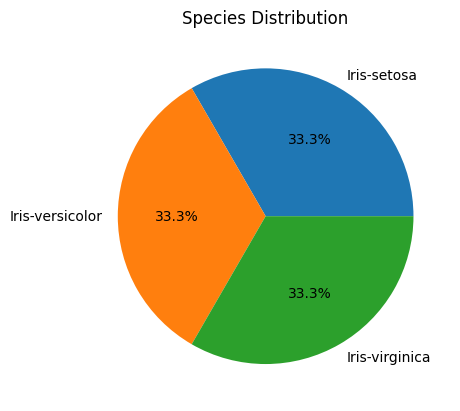

In [6]:
species_count = df['species'].value_counts()

plt.pie(
    species_count,
    labels=species_count.index,
    autopct='%1.1f%%'
)

plt.title("Species Distribution")
plt.show()

Bar Chart

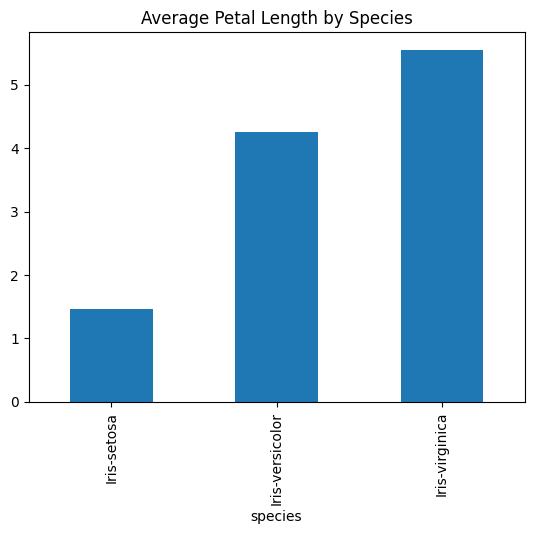

In [7]:
df.groupby('species')['petal_length'].mean().plot(kind='bar')

plt.title("Average Petal Length by Species")
plt.show()

Line Chart

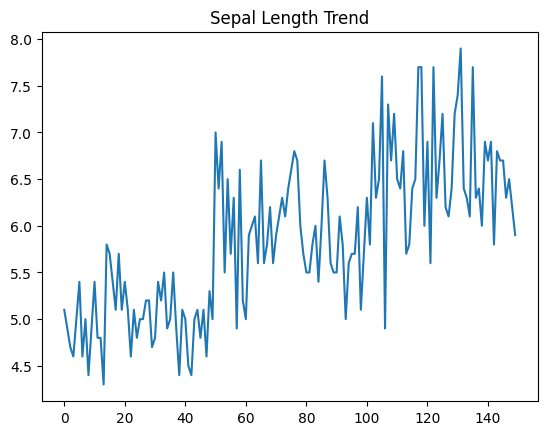

In [8]:
plt.plot(df.index, df['sepal_length'])

plt.title("Sepal Length Trend")
plt.show()

Select Input and Output

In [9]:
X = df[['sepal_length', 'sepal_width', 'petal_width']]

y = df['petal_length']

Split Dataset into Training and Testing

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Apply Simple Linear Regression Model

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Generate Results on Testing Dataset

In [12]:
y_pred = model.predict(X_test)

Display Results

In [13]:
print("Actual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)

Actual Values:
[4.7 1.7 6.9 4.5 4.8 1.5 3.6 5.1 4.5 3.9 5.1 1.4 1.3 1.5 1.5 4.7 5.8 3.9
 4.5 5.6 1.6 4.9 1.6 5.6 6.4 5.2 5.8 5.9 1.4 1.6]

Predicted Values:
[4.12907977 1.87775771 7.02910351 4.43236278 4.92926532 2.0639232
 3.84942915 6.12878356 5.02657149 3.97602415 5.33502143 1.44630795
 1.7788798  1.45452896 1.44325388 4.5394617  5.75667844 3.81294994
 3.98604275 5.81265373 1.39213025 4.8804804  1.77425398 5.66602153
 5.96368591 6.04814525 5.63596573 5.99216996 1.73957236 1.52874386]


Show Results in Table Form

In [14]:
import pandas as pd

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(results)

    Actual  Predicted
0      4.7   4.129080
1      1.7   1.877758
2      6.9   7.029104
3      4.5   4.432363
4      4.8   4.929265
5      1.5   2.063923
6      3.6   3.849429
7      5.1   6.128784
8      4.5   5.026571
9      3.9   3.976024
10     5.1   5.335021
11     1.4   1.446308
12     1.3   1.778880
13     1.5   1.454529
14     1.5   1.443254
15     4.7   4.539462
16     5.8   5.756678
17     3.9   3.812950
18     4.5   3.986043
19     5.6   5.812654
20     1.6   1.392130
21     4.9   4.880480
22     1.6   1.774254
23     5.6   5.666022
24     6.4   5.963686
25     5.2   6.048145
26     5.8   5.635966
27     5.9   5.992170
28     1.4   1.739572
29     1.6   1.528744


In [15]:
import numpy as np

threshold = np.median(y_test)

y_test_class = (y_test >= threshold).astype(int)
y_pred_class = (y_pred >= threshold).astype(int)

Evaluation metrics

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test_class, y_pred_class))
print("Precision:", precision_score(y_test_class, y_pred_class))
print("Recall:", recall_score(y_test_class, y_pred_class))
print("F1 Score:", f1_score(y_test_class, y_pred_class))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_class))

Accuracy: 0.9
Precision: 1.0
Recall: 0.8235294117647058
F1 Score: 0.9032258064516129

Confusion Matrix:
[[13  0]
 [ 3 14]]


Training Dataset

In [17]:
y_train_pred = model.predict(X_train)

In [19]:
import pandas as pd

train_results = pd.DataFrame({
    'Actual': y_train.values,
    'Predicted': y_train_pred
})

train_results

,Actual,Predicted
0,1.0,1.062928
1,1.5,1.639212
2,4.4,4.664259
3,1.6,1.336155
4,1.3,1.174878
...,...,...
115,4.0,4.275712
116,4.5,4.185822
117,1.2,1.675150
118,4.0,4.040220


Testing Dataset

In [18]:
y_test_pred = model.predict(X_test)

In [20]:
test_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_test_pred
})

test_results

,Actual,Predicted
0,4.7,4.129080
1,1.7,1.877758
2,6.9,7.029104
3,4.5,4.432363
4,4.8,4.929265
5,1.5,2.063923
6,3.6,3.849429
7,5.1,6.128784
8,4.5,5.026571
9,3.9,3.976024
